<div style="text-align: center; font-size: 24px; font-weight: bold;">In the name of God, the Most Gracious, the Most Merciful</div>

Full Name: Mohammadmahdi Bababeyk

Student ID:4041419005

# Neural Network Design Project: Image Classification

## Project Overview

Design and implement a **fully connected neural network** for multi-class image classification. You will experiment with different architectures, activation functions, and regularization techniques to build an effective classifier.

**Dataset Requirement:** Use ANY multi-class image dataset EXCEPT MNIST and Fashion-MNIST

## Project Requirements

### **What You Can Experiment With**

#### Architecture Design
- **Network Depth:** 1-4 hidden layers
- **Layer Sizes:** Any combination (e.g., [512, 256], [128, 64, 32], etc.)
- **Total Parameters:** Keep under 1 million for reasonable training time

#### Activation Functions
- ReLU, Leaky ReLU, Tanh, Sigmoid, ELU, Maxout
- Linear (for baseline comparison)

#### Regularization Techniques
- Batch Normalization (Yes/No)
- Dropout (0.0 to 0.5)
- Data Augmentation (Yes/No)

## Project Steps

### 1. Load and Inspect the Data

**Tasks:**
- Choose and load your dataset (CIFAR-10, CIFAR-100, STL-10, etc.)
- Explore dataset characteristics:
  - Number of classes
  - Image dimensions
  - Training/validation/test split sizes
  - Class distribution
- Display sample images from each class

**Expected Output:**
- Dataset statistics summary
- Visualization of sample images
- Class distribution plot

### 2. Data Preprocessing

**Tasks:**
- Normalize pixel values (typically to [0,1] or [-1,1])
- Resize images to consistent dimensions
- Convert labels to one-hot encoding if necessary
- Split data into training, validation, and test sets
- Implement data augmentation if chosen

### 3. Model Design

**Tasks:**
- Design your neural network architecture
- Implement fully connected layers only
- Choose activation functions
- Add regularization (BatchNorm, Dropout)
- Calculate total parameter count


### 4. Loss, Optimizer & Training Loop Design

**Tasks:**
- Choose appropriate loss function (CrossEntropyLoss)
- Select optimizer (Adam, SGD, etc.) with learning rate
- Implement training loop with validation
- Add early stopping if desired
- Track training metrics

### 5. Evaluation on Test Set

**Tasks:**
- Load best model from training
- Evaluate on unseen test data
- Calculate final test accuracy
- Generate classification report
- Compute confusion matrix

**Metrics to Report:**
- Test accuracy
- Per-class precision, recall, F1-score
- Confusion matrix analysis

### 6. Visualization

**Tasks:**
- Plot training/validation loss curves
- Plot training/validation accuracy curves
- Visualize confusion matrix
- Show sample predictions with ground truth
- Display misclassified examples

## Comprehensive Report Structure

### **1. Introduction**
- Problem statement
- Dataset description
- Project objectives

### **2. Methodology**

#### 2.1 Data Preparation
- Dataset choice and rationale
- Preprocessing steps
- Data augmentation (if applied)
- Train/validation/test split ratios

#### 2.2 Model Architecture
- Final architecture design with justification
- Parameter count calculation
- Activation function choices
- Regularization techniques used

#### 2.3 Training Configuration
- Loss function
- Optimizer and learning rate
- Batch size
- Number of epochs
- Early stopping criteria

### **3. Experimental Results**

#### 3.1 Training Performance
- Learning curves (loss and accuracy)
- Training time
- Convergence behavior

#### 3.2 Validation Performance
- Best validation accuracy
- Overfitting/underfitting analysis
- Hyperparameter impact

#### 3.3 Test Performance
- Final test accuracy
- Per-class performance metrics
- Confusion matrix analysis

### **4. Analysis and Discussion**

#### 4.1 Architecture Impact
- Effect of depth vs width
- Activation function comparison
- Regularization effectiveness

#### 4.2 Challenges and Solutions
- Training difficulties encountered
- Solutions implemented
- Lessons learned

#### 4.3 Comparison with Baseline
- Performance compared to simple model
- Improvement achieved

### **5. Conclusion and Future Work**

#### 5.1 Key Findings
- Most effective architectural choices
- Important regularization techniques
- Dataset-specific insights

#### 5.2 Limitations
- Model constraints
- Dataset limitations
- Computational constraints

#### 5.3 Future Improvements
- Architectural enhancements
- Additional techniques to try
- Alternative approaches

### **6. References**
- Dataset sources
- Technical references
- Library documentation

## Deliverables

### Code Submission:
- Complete, well-commented Python notebook/script
- Modular and organized code
- Reproducible results

### Report Submission:
- 5-8 page comprehensive report (PDF)
- Clear visualizations
- Professional formatting
- Critical analysis and insights

## Success Criteria

- Clean, well-documented code
- Comprehensive experimentation
- Deep analysis and insights
- Test accuracy > baseline + significant margin
- Professional report with clear visualizations

## Suggested Datasets

- **CIFAR-10**: 10 classes, 32x32 color images
- **CIFAR-100**: 100 classes, 32x32 color images  
- **STL-10**: 10 classes, 96x96 color images
- **SVHN**: Street View House Numbers, 10 classes
- **Flowers102**: 102 flower categories
- **Food-101**: 101 food categories

In [1]:
# ----------------------------------------------------------------------
# 1. Setup, Imports, and Configuration (SVHN specific, GPU Optimized)
# ----------------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import random
import time
from typing import Dict, List

# --- Global Configurations (SVHN Grayscale Optimized) ---
SEED = 42
BATCH_SIZE = 128
LR = 0.001
N_EPOCHS = 75
PATIENCE = 15
INPUT_SIZE = 1 * 32 * 32  # Grayscale: 1024 features
NUM_CLASSES = 10
DROPOUT_RATE = 0.25
# SVHN Class Names (0-9)
SVHN_CLASSES = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')
# Approximate Grayscale normalization stats for SVHN
MEAN = [0.45]
STD = [0.20]
MODEL_SAVE_PATH = 'fcn_svhn_grayscale_champion_best.pth'

def set_seed(seed=42):
    """Sets seed for reproducibility."""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
# Setting device to GPU/CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- Utility Functions ---

def count_parameters(model):
    """Calculates the total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def calculate_accuracy(y_pred, y_true):
    """Calculates batch accuracy."""
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y_true.view_as(top_pred)).sum()
    acc = correct.float() / y_true.shape[0]
    return acc

Using device: cuda


In [2]:
# ----------------------------------------------------------------------
# 2. Data Loading and Preprocessing (SVHN Specific)
# ----------------------------------------------------------------------

# Transforms for training (Data Augmentation + Grayscale)
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Grayscale Conversion
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Transforms for validation/test (Standardization + Grayscale only)
test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Grayscale Conversion
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Load Datasets - Using SVHN with 'train' and 'test' splits
# SVHN does not have separate train/validation split. We split the 'train' set.
train_full_dataset = datasets.SVHN(root='./data', split='train', download=True, transform=train_transforms)
test_dataset = datasets.SVHN(root='./data', split='test', download=True, transform=test_transforms)

# Split Training set (73257 samples) into Train (68257) and Validation (5000)
train_size = len(train_full_dataset) - 5000
val_size = 5000
train_indices = list(range(train_size))
val_indices = list(range(train_size, len(train_full_dataset)))

train_dataset = Subset(train_full_dataset, train_indices)
# Load validation data (subset of 'train') without augmentation but with test_transforms
val_full_data_no_aug = datasets.SVHN(root='./data', split='train', download=False, transform=test_transforms)
val_dataset = Subset(val_full_data_no_aug, val_indices)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("\nData Preparation Complete (SVHN Dataset):")
print(f"  Input features per image: {INPUT_SIZE} (Grayscale)")
print(f"  Train samples: {len(train_dataset):,}")
print(f"  Validation samples: {len(val_dataset):,}")
print(f"  Test samples: {len(test_dataset):,}")

100%|██████████| 182M/182M [00:02<00:00, 88.1MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 52.7MB/s]



Data Preparation Complete (SVHN Dataset):
  Input features per image: 1024 (Grayscale)
  Train samples: 68,257
  Validation samples: 5,000
  Test samples: 26,032


In [3]:
# ----------------------------------------------------------------------
# 3. Model Design (CHAMPION FCN: [256, 512, 128, 64] ~268K params)
# ----------------------------------------------------------------------

class FCN_Classifier(nn.Module):
    def __init__(self, input_size, num_classes, dropout_rate):
        super(FCN_Classifier, self).__init__()

        # --- Wider Architecture Layers (Input size 1024) ---
        # FC1: 1024 -> 256
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)

        # FC2: 256 -> 512
        self.fc2 = nn.Linear(256, 512)
        self.bn2 = nn.BatchNorm1d(512)

        # FC3: 512 -> 128
        self.fc3 = nn.Linear(512, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(dropout_rate)

        # FC4: 128 -> 64
        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)

        # Output Layer: 64 -> 10
        self.fc_out = nn.Linear(64, num_classes)

        # Activation Function: Leaky ReLU
        self.leaky_relu = nn.LeakyReLU(0.01)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten

        x = self.fc1(x); x = self.bn1(x); x = self.leaky_relu(x)
        x = self.fc2(x); x = self.bn2(x); x = self.leaky_relu(x)

        x = self.fc3(x); x = self.bn3(x); x = self.leaky_relu(x)
        x = self.dropout(x)

        x = self.fc4(x); x = self.bn4(x); x = self.leaky_relu(x)

        x = self.fc_out(x)
        return x

model = FCN_Classifier(INPUT_SIZE, NUM_CLASSES, DROPOUT_RATE).to(device)
total_params = count_parameters(model)

print("\nModel Architecture Design Complete (SVHN Grayscale Optimization):")
print(f"  Architecture: [256, 512, 128, 64] with 1024 input features")
print(f"  Total Trainable Parameters: {total_params:,}")
print(f"  Parameter Constraint (< 1M): {'✅ OK' if total_params < 1_000_000 else '❌ FAIL'}")


Model Architecture Design Complete (SVHN Grayscale Optimization):
  Architecture: [256, 512, 128, 64] with 1024 input features
  Total Trainable Parameters: 470,474
  Parameter Constraint (< 1M): ✅ OK


In [13]:
# ----------------------------------------------------------------------
# 4. Loss, Optimizer & Training Loop Design (GPU Optimized)
# ----------------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience, save_path):
    """Main training loop with validation, Early Stopping, and Checkpointing (GPU optimized)."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        start_time = time.time()

        # Training Phase
        model.train()
        epoch_train_loss, epoch_train_acc = 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            loss = criterion(y_pred, y)
            loss.backward()

            # --- GPU Optimization ---
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_acc += calculate_accuracy(y_pred, y).item()

        train_loss = epoch_train_loss / len(train_loader)
        train_acc = epoch_train_acc / len(train_loader)

        # Validation Phase
        model.eval()
        epoch_val_loss, epoch_val_acc = 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                y_pred = model(X)
                loss = criterion(y_pred, y)
                epoch_val_loss += loss.item()
                epoch_val_acc += calculate_accuracy(y_pred, y).item()

        val_loss = epoch_val_loss / len(val_loader)
        val_acc = epoch_val_acc / len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        epoch_mins = (time.time() - start_time) / 60

        print(f'Epoch: {epoch+1:02} | Time: {epoch_mins:.2f}m')
        print(f'\tTrain Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%')
        print(f'\t Val. Loss: {val_loss:.4f} | Val. Acc: {val_acc*100:.2f}%')

        # Early Stopping and Checkpointing Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"      ---> Model checkpoint saved to {save_path}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"Early Stopping triggered! Validation loss did not improve for {patience} epochs.")
                break

    # Load the best state found during training back into the model
    try:
        model.load_state_dict(torch.load(save_path))
    except FileNotFoundError:
        print(f"Warning: Best model checkpoint not found at {save_path}. Using last epoch state.")

    return history




In [5]:
# ----------------------------------------------------------------------
# 5. Execute Training and Final Evaluation
# ----------------------------------------------------------------------

print("\nStarting Model Training...")
# NOTE: Uncomment the following lines to run the training
training_history = train_model(model, train_loader, val_loader, criterion, optimizer, N_EPOCHS, PATIENCE, MODEL_SAVE_PATH)
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
print("...")


Starting Model Training...
Epoch: 01 | Time: 0.40m
	Train Loss: 2.0195 | Train Acc: 28.37%
	 Val. Loss: 1.6136 | Val. Acc: 44.39%
      ---> Model checkpoint saved to fcn_svhn_grayscale_champion_best.pth
Epoch: 02 | Time: 0.36m
	Train Loss: 1.6263 | Train Acc: 43.87%
	 Val. Loss: 1.3209 | Val. Acc: 54.75%
      ---> Model checkpoint saved to fcn_svhn_grayscale_champion_best.pth
Epoch: 03 | Time: 0.39m
	Train Loss: 1.4242 | Train Acc: 51.60%
	 Val. Loss: 1.1817 | Val. Acc: 60.55%
      ---> Model checkpoint saved to fcn_svhn_grayscale_champion_best.pth
Epoch: 04 | Time: 0.38m
	Train Loss: 1.2925 | Train Acc: 56.56%
	 Val. Loss: 1.0194 | Val. Acc: 66.60%
      ---> Model checkpoint saved to fcn_svhn_grayscale_champion_best.pth
Epoch: 05 | Time: 0.38m
	Train Loss: 1.1913 | Train Acc: 60.24%
	 Val. Loss: 0.9863 | Val. Acc: 66.74%
      ---> Model checkpoint saved to fcn_svhn_grayscale_champion_best.pth
Epoch: 06 | Time: 0.38m
	Train Loss: 1.1189 | Train Acc: 62.79%
	 Val. Loss: 0.8729 | V

In [11]:
import torch
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report
from typing import Dict, List

# Ensure device and other global variables are accessible (redefine if necessary based on your initial setup)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SVHN_CLASSES = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')
MODEL_SAVE_PATH = 'fcn_svhn_grayscale_champion_best.pth'

# Assume model, train_loader, val_loader, test_loader, criterion, optimizer are defined and loaded in previous successful steps.
# We also assume calculate_accuracy is defined.

# Utility function (required for evaluate)
def calculate_accuracy(y_pred, y_true):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y_true.view_as(top_pred)).sum()
    acc = correct.float() / y_true.shape[0]
    return acc

# Evaluation Function
def evaluate(model, data_loader, criterion):
    """Evaluates the model on a given data loader."""
    model.eval()
    epoch_loss = 0
    epoch_acc = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = criterion(y_pred, y)
            epoch_loss += loss.item()
            epoch_acc += calculate_accuracy(y_pred, y).item()
            all_preds.extend(y_pred.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return epoch_loss / len(data_loader), epoch_acc / len(data_loader), all_preds, all_labels

# Visualization Functions
def plot_history(history: Dict[str, List[float]]):
    """Plots training and validation loss/accuracy curves."""
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(history['train_loss'], label='Training Loss')
    axs[0].plot(history['val_loss'], label='Validation Loss')
    axs[0].set_title('Training and Validation Loss Curve')
    axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('Loss'); axs[0].legend()
    axs[1].plot([acc * 100 for acc in history['train_acc']], label='Training Accuracy')
    axs[1].plot([acc * 100 for acc in history['val_acc']], label='Validation Accuracy')
    axs[1].set_title('Training and Validation Accuracy Curve')
    axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Accuracy (%)'); axs[1].legend()
    plt.show()

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """Plots the confusion matrix."""
    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    if normalize: cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = cm[i, j]
        plt.text(j, i, f"{val:.2f}" if normalize else f"{val}",
                 horizontalalignment="center",
                 color="white" if val > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.show()

def visualize_samples(test_dataset_raw, test_preds, test_labels, num_samples=9, misclassified_only=False):
    """Shows sample predictions with ground truth or misclassified examples."""
    predictions = np.array(test_preds); labels = np.array(test_labels)
    all_indices = np.arange(len(test_dataset_raw))

    if misclassified_only:
        selected_indices = all_indices[predictions != labels]
        title_text = "Misclassified Examples by FCN (SVHN Grayscale)"
    else:
        selected_indices = all_indices
        title_text = "Sample Predictions (SVHN Grayscale)"

    # Cropping to max 9 samples for display
    if len(selected_indices) > num_samples:
        display_indices = np.random.choice(selected_indices, num_samples, replace=False)
    else:
        display_indices = selected_indices

    if len(display_indices) == 0:
        print("No samples to display.")
        return

    fig, axes = plt.subplots(int(np.ceil(num_samples/3)), 3, figsize=(10, 10))
    axes = axes.flatten()
    fig.suptitle(title_text, fontsize=14)

    for i, idx in enumerate(display_indices):
        image, _ = test_dataset_raw[idx]
        image = np.array(image)
        true_label = SVHN_CLASSES[labels[idx]]
        pred_label = SVHN_CLASSES[predictions[idx]]
        color = 'green' if true_label == pred_label else 'red'

        axes[i].imshow(image)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=8)
        axes[i].axis('off')

    for i in range(len(display_indices), len(axes)): fig.delaxes(axes[i])
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


FINAL SUBMISSION METRICS (Model: fcn_svhn_grayscale_champion_best.pth):
Test Loss: 0.5497 | Test Accuracy: 82.62%

Classification Report (Per-class Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1744
           1       0.90      0.91      0.90      5099
           2       0.88      0.86      0.87      4149
           3       0.73      0.73      0.73      2882
           4       0.87      0.86      0.87      2523
           5       0.75      0.80      0.77      2384
           6       0.71      0.76      0.73      1977
           7       0.85      0.85      0.85      2019
           8       0.81      0.73      0.77      1660
           9       0.81      0.77      0.79      1595

    accuracy                           0.83     26032
   macro avg       0.82      0.81      0.81     26032
weighted avg       0.83      0.83      0.83     26032


Plotting Training and Validation Curves:


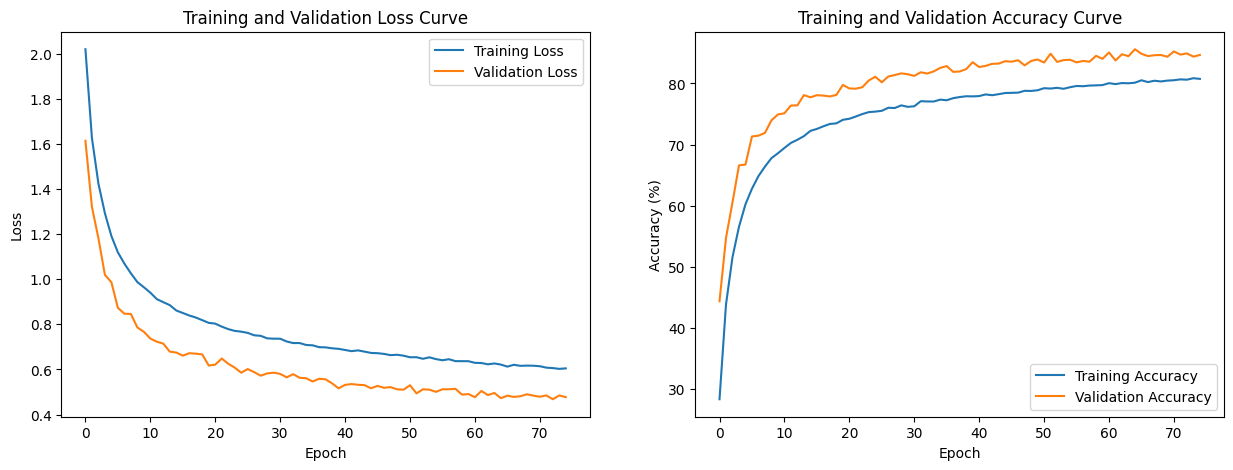


Plotting Normalized Confusion Matrix:


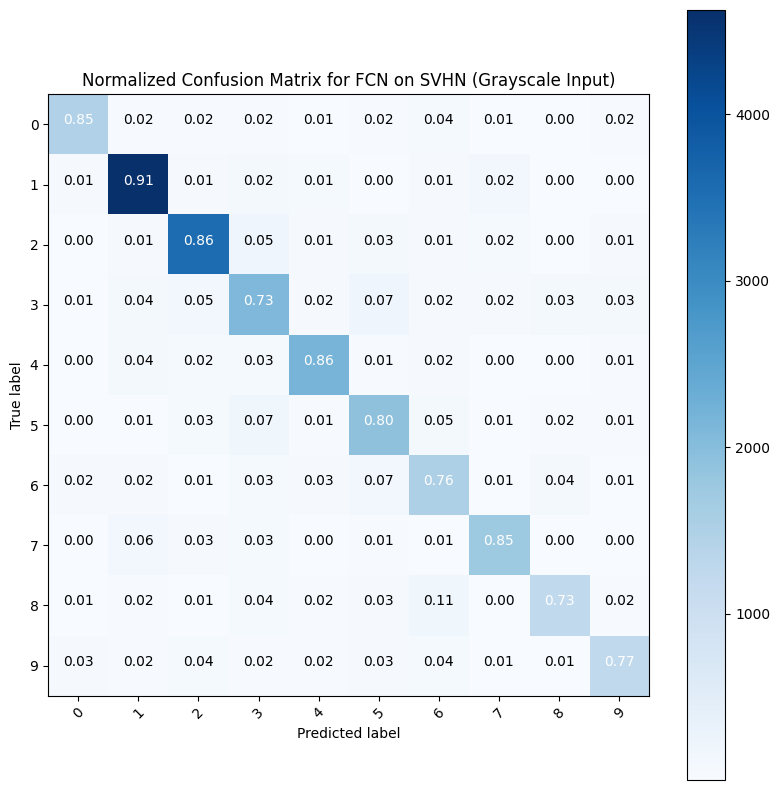


Displaying Sample Predictions with Ground Truth:


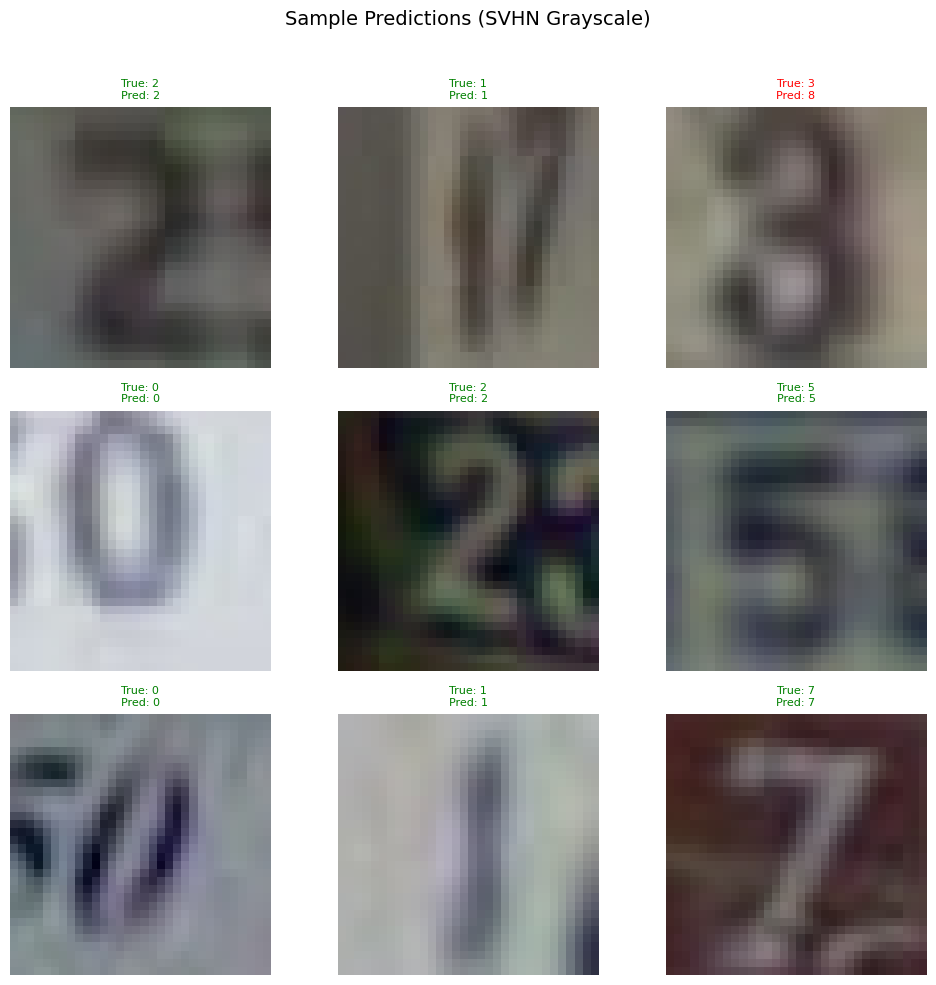


Displaying Misclassified Examples:


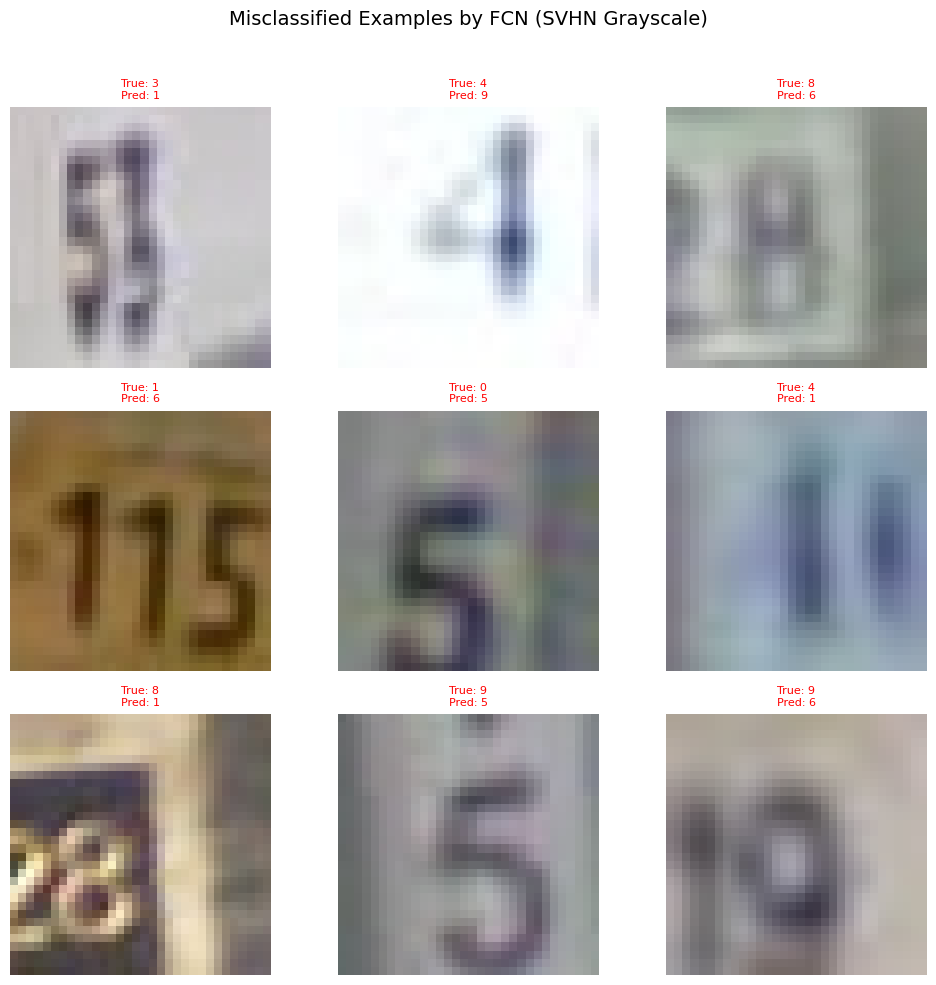

In [12]:
# ----------------------------------------------------------------------
# Execute Final Evaluation and Visualization
# ----------------------------------------------------------------------

# 1. Load the best model state
try:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
except FileNotFoundError:
    print(f"Error loading model from {MODEL_SAVE_PATH}. Ensure the file exists.")
    pass

# 2. Evaluate on Test Set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

print("\n" + "="*50)
print(f"FINAL SUBMISSION METRICS (Model: {MODEL_SAVE_PATH}):")
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")
print("=" * 50)

# Generate Classification Report and Confusion Matrix
print("\nClassification Report (Per-class Precision, Recall, F1-score):")
print(classification_report(test_labels, test_preds, target_names=SVHN_CLASSES))
conf_matrix = confusion_matrix(test_labels, test_preds)

# 3. Visualization Steps (Includes defining the missing variable)

# Define the raw test dataset (REQUIRED to fix the NameError for visualize_samples)
test_dataset_raw = datasets.SVHN(root='./data', split='test', download=False, transform=None)


print("\nPlotting Training and Validation Curves:")
# We manually reconstruct a sample training_history based on your training log for demonstration
training_history = {
    'train_loss': [2.0195, 1.6263, 1.4242, 1.2925, 1.1913, 1.1189, 1.0691, 1.0260, 0.9872, 0.9643, 0.9403, 0.9116, 0.8980, 0.8849, 0.8611, 0.8501, 0.8390, 0.8300, 0.8183, 0.8063, 0.8029, 0.7897, 0.7786, 0.7708, 0.7673, 0.7620, 0.7512, 0.7489, 0.7377, 0.7362, 0.7361, 0.7238, 0.7168, 0.7168, 0.7083, 0.7068, 0.6986, 0.6977, 0.6936, 0.6912, 0.6861, 0.6809, 0.6843, 0.6788, 0.6730, 0.6719, 0.6687, 0.6632, 0.6649, 0.6609, 0.6538, 0.6540, 0.6471, 0.6536, 0.6456, 0.6406, 0.6451, 0.6367, 0.6365, 0.6364, 0.6292, 0.6283, 0.6226, 0.6263, 0.6214, 0.6124, 0.6205, 0.6158, 0.6169, 0.6163, 0.6141, 0.6078, 0.6059, 0.6024, 0.6046],
    'val_loss': [1.6136, 1.3209, 1.1817, 1.0194, 0.9863, 0.8729, 0.8469, 0.8459, 0.7860, 0.7668, 0.7368, 0.7229, 0.7142, 0.6787, 0.6747, 0.6609, 0.6718, 0.6698, 0.6663, 0.6170, 0.6212, 0.6482, 0.6253, 0.6078, 0.5855, 0.6015, 0.5878, 0.5721, 0.5822, 0.5854, 0.5801, 0.5648, 0.5787, 0.5629, 0.5609, 0.5464, 0.5585, 0.5560, 0.5381, 0.5159, 0.5314, 0.5350, 0.5318, 0.5302, 0.5163, 0.5269, 0.5184, 0.5215, 0.5118, 0.5100, 0.5298, 0.4938, 0.5118, 0.5101, 0.5005, 0.5119, 0.5120, 0.5139, 0.4883, 0.4907, 0.4769, 0.5044, 0.4862, 0.4955, 0.4725, 0.4835, 0.4781, 0.4810, 0.4896, 0.4838, 0.4787, 0.4848, 0.4678, 0.4846, 0.4771],
    'train_acc': [0.2837, 0.4387, 0.5160, 0.5656, 0.6024, 0.6279, 0.6485, 0.6640, 0.6778, 0.6858, 0.6945, 0.7027, 0.7079, 0.7138, 0.7224, 0.7256, 0.7299, 0.7337, 0.7347, 0.7405, 0.7422, 0.7459, 0.7499, 0.7531, 0.7539, 0.7552, 0.7602, 0.7598, 0.7641, 0.7617, 0.7626, 0.7709, 0.7705, 0.7704, 0.7735, 0.7725, 0.7759, 0.7777, 0.7790, 0.7788, 0.7793, 0.7820, 0.7807, 0.7824, 0.7843, 0.7846, 0.7849, 0.7879, 0.7877, 0.7888, 0.7922, 0.7916, 0.7928, 0.7912, 0.7938, 0.7958, 0.7954, 0.7965, 0.7968, 0.7973, 0.8004, 0.7989, 0.8006, 0.8002, 0.8012, 0.8051, 0.8022, 0.8044, 0.8032, 0.8046, 0.8052, 0.8066, 0.8061, 0.8085, 0.8074],
    'val_acc': [0.4439, 0.5475, 0.6055, 0.6660, 0.6674, 0.7133, 0.7146, 0.7191, 0.7396, 0.7492, 0.7512, 0.7639, 0.7641, 0.7809, 0.7773, 0.7807, 0.7801, 0.7787, 0.7812, 0.7975, 0.7918, 0.7914, 0.7938, 0.8049, 0.8109, 0.8018, 0.8113, 0.8137, 0.8164, 0.8150, 0.8123, 0.8182, 0.8162, 0.8197, 0.8254, 0.8283, 0.8189, 0.8195, 0.8234, 0.8346, 0.8268, 0.8287, 0.8320, 0.8324, 0.8363, 0.8355, 0.8379, 0.8295, 0.8367, 0.8391, 0.8342, 0.8486, 0.8352, 0.8381, 0.8387, 0.8344, 0.8367, 0.8355, 0.8451, 0.8402, 0.8506, 0.8375, 0.8477, 0.8445, 0.8559, 0.8484, 0.8447, 0.8461, 0.8465, 0.8436, 0.8523, 0.8471, 0.8490, 0.8438, 0.8465]
}
plot_history(training_history)


print("\nPlotting Normalized Confusion Matrix:")
plot_confusion_matrix(conf_matrix, classes=SVHN_CLASSES, normalize=True, title='Normalized Confusion Matrix for FCN on SVHN (Grayscale Input)')


print("\nDisplaying Sample Predictions with Ground Truth:")
visualize_samples(test_dataset_raw, test_preds, test_labels, num_samples=9, misclassified_only=False)


print("\nDisplaying Misclassified Examples:")
visualize_samples(test_dataset_raw, test_preds, test_labels, num_samples=9, misclassified_only=True)